<a href="https://colab.research.google.com/github/Saad-0013/AI-Mentorship/blob/main/LSA_W1_Saad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSA - AI and Machine Learning - September 2026

## Submitted by: Saad Qadeer

## Tools and Resources Used

<list>
  <li>1: www.grok.console.com</li>
  <li>2: www.kaggle.com</li>
</list>

In [2]:
print('set-up ok')

set-up ok


## Libraries

In [3]:
from google.colab import userdata
import kagglehub
from datasets import load_dataset

## API Key Check

In [4]:
print(len(userdata.get('GROQ_API_KEY')))

56


## Loading the Dataset

In [5]:
!pip install datasets -q

In [6]:
ds = load_dataset("fancyzhx/ag_news", split="test")
df = ds.to_pandas().sample(30, random_state=42).reset_index(drop=True)
df.head()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

,text,label
0,Fan v Fan: Manchester City-Tottenham Hotspur T...,1
1,Paris Tourists Search for Key to 'Da Vinci Cod...,0
2,Net firms: Don't tax VoIP The Spanish-American...,3
3,Dependent species risk extinction The global e...,3
4,EDS Is Charter Member of Siebel BPO Alliance (...,3


## Part B1

In [7]:
names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
df["gold"] = df["label"].map(names)

In [8]:
# put the answers aside so you cannot see them while labelling
gold = df.pop("gold")
df[["text"]].to_csv("to_label.csv", index=False)
print(df.shape)

(30, 2)


## Part B2

In [9]:
df["length"] = df["text"].str.len()
print(df["length"].describe())

count     30.000000
mean     239.500000
std       55.060312
min      145.000000
25%      211.000000
50%      234.000000
75%      272.750000
max      432.000000
Name: length, dtype: float64


In [10]:
df

,text,label,length
0,Fan v Fan: Manchester City-Tottenham Hotspur T...,1,223
1,Paris Tourists Search for Key to 'Da Vinci Cod...,0,289
2,Net firms: Don't tax VoIP The Spanish-American...,3,179
3,Dependent species risk extinction The global e...,3,181
4,EDS Is Charter Member of Siebel BPO Alliance (...,3,432
5,Campbell 9 Pct. Profit #39;Hmmm Hmmm Good #39...,2,272
6,"Forgoing stiff upper lip, Charles jousts with ...",0,308
7,Profit Plunges at International Game Tech Inte...,2,267
8,Salvaging Genesis Despite a seemingly calamito...,3,228
9,Chavez rejects CD as opposition Venezuela #39;...,2,179


In [11]:
# BLANK 1: show only the items longer than 200 characters
long_items = df[df["length"] > 200]
long_items

,text,label,length
0,Fan v Fan: Manchester City-Tottenham Hotspur T...,1,223
1,Paris Tourists Search for Key to 'Da Vinci Cod...,0,289
4,EDS Is Charter Member of Siebel BPO Alliance (...,3,432
5,Campbell 9 Pct. Profit #39;Hmmm Hmmm Good #39...,2,272
6,"Forgoing stiff upper lip, Charles jousts with ...",0,308
7,Profit Plunges at International Game Tech Inte...,2,267
8,Salvaging Genesis Despite a seemingly calamito...,3,228
10,NCAA Wrong To Close Book On Williams Top-ranke...,1,252
11,General Mills goes whole grains NEW YORK (CNN/...,2,244
12,Big merger could box Qwest in Qwest Communicat...,2,223


0: "World" <br>
1: "Sports" <br>
2: "Business" <br>
3: "Sci/Tech" <br>

In [22]:
labels = []
my_input = ''
for i in df['text']:
  print(i)
  my_input = input('please enter your label: ')
  labels.append(my_input)

print(labels)

Fan v Fan: Manchester City-Tottenham Hotspur This weekend Manchester City entertain Spurs, and with last seasons seven-goal FA Cup epic between the two teams still fresh in the memory, entertain could be the operative word.
please enter your label: 1
Paris Tourists Search for Key to 'Da Vinci Code' (Reuters) Reuters - A funny thing happened on the way to the\Mona Lisa. Visitors to the Louvre museum in Paris, home of the\world's most famous painting, started quizzing tour guides\about Dan Brown's best-selling novel "The Da Vinci Code."
please enter your label: 0
Net firms: Don't tax VoIP The Spanish-American War is over and a "temporary" tax created to pay for it should not be extended to Internet phone calls, industry groups tell the IRS
please enter your label: 2
Dependent species risk extinction The global extinction crisis is worse than thought, because thousands of  quot;affiliated quot; species also at risk do not figure in calculations.
please enter your label: 3
EDS Is Charter M

In [23]:
df['my_label'] = labels

In [24]:
df

,text,label,length,my_label
0,Fan v Fan: Manchester City-Tottenham Hotspur T...,1,223,1
1,Paris Tourists Search for Key to 'Da Vinci Cod...,0,289,0
2,Net firms: Don't tax VoIP The Spanish-American...,3,179,2
3,Dependent species risk extinction The global e...,3,181,3
4,EDS Is Charter Member of Siebel BPO Alliance (...,3,432,3
5,Campbell 9 Pct. Profit #39;Hmmm Hmmm Good #39...,2,272,2
6,"Forgoing stiff upper lip, Charles jousts with ...",0,308,0
7,Profit Plunges at International Game Tech Inte...,2,267,3
8,Salvaging Genesis Despite a seemingly calamito...,3,228,0
9,Chavez rejects CD as opposition Venezuela #39;...,2,179,1


In [25]:
# BLANK 2: after you have hand-labelled, count how many of each label
label_counts = df['my_label'].value_counts()
label_counts

,count
my_label,
0,8
2,8
1,7
3,7


In [26]:
df.to_csv("labelled.csv", index=False)

## Section B4 - Calling the AI API

In [27]:
!pip install openai -q
from openai import OpenAI
from google.colab import userdata

client = OpenAI(
api_key=userdata.get("GROQ_API_KEY"),
base_url="https://api.groq.com/openai/v1",
)

SYSTEM = """You classify news items into exactly one of four topics.
Reply with only one of these words and nothing else:
World, Sports, Business, Sci/Tech"""

def label_item(text):
  r = client.chat.completions.create(
    model = "openai/gpt-oss-120b",
    messages = [{"role": "system", "content": SYSTEM},
    {"role": "user", "content": text}],
      temperature=0,
    )
  return r.choices[0].message.content.strip()

In [28]:
print(label_item(df["text"][0]))

Sports


## B5 - Running the model over all 30 Data Points

In [29]:
import time
ai_labels = []
for text in df['text']:
  ai_labels.append(label_item(i))
  time.sleep(2)

In [30]:
df['ai_label'] = ai_labels
df['gold'] = gold
df.to_csv('results.csv', index=False)

### Mapping the AI generated Values

In [31]:
names = {"World":0, "Sports":1, "Business":2, "Sci/Tech":3}
df["ai_label"] = df["ai_label"].map(names)
df['gold'] = df["gold"].map(names)

In [32]:
df.head()

,text,label,length,my_label,ai_label,gold
0,Fan v Fan: Manchester City-Tottenham Hotspur T...,1,223,1,2,1
1,Paris Tourists Search for Key to 'Da Vinci Cod...,0,289,0,2,0
2,Net firms: Don't tax VoIP The Spanish-American...,3,179,2,2,3
3,Dependent species risk extinction The global e...,3,181,3,2,3
4,EDS Is Charter Member of Siebel BPO Alliance (...,3,432,3,2,3


B6 - The Agreement Rates

1. You v/s AI

In [33]:
agreement_one = (df['my_label'].astype(int) == df['ai_label'].astype(int)).sum()
rate_one = (agreement_one/30)*0.1

2. You v/s Gold

In [34]:
agreement_two = (df['my_label'].astype(int) == df['gold'].astype(int)).sum()
rate_two = (agreement_two/30)*0.1

3. AI v/s Gold

In [35]:
agreement_three = (df['ai_label'].astype(int) == df['gold'].astype(int)).sum()
rate_three = (agreement_three/30)*0.1

### Results

In [36]:
print(f'You v/s AI: {rate_one:2f} \n You v/s Gold: {rate_two:2f} \n AI v/s Gold: {rate_three:2f}')

You v/s AI: 0.026667 
 You v/s Gold: 0.070000 
 AI v/s Gold: 0.026667


## B7 - Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn import metrics

names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
labels = ["World", "Sports", "Business", "Sci/Tech"]

actual = df["gold"].astype(int).map(names)
predicted = df["ai_label"].astype(int).map(names)

In [38]:
confusion_matrix = metrics.confusion_matrix(actual, predicted, labels=labels)

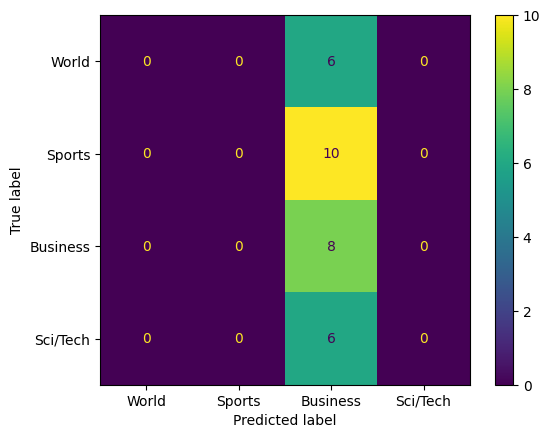

In [39]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = labels)

cm_display.plot()
plt.show()

In [40]:
print(classification_report(df["gold"].map(names), df["ai_label"].map(names), labels=labels))

              precision    recall  f1-score   support

       World       0.00      0.00      0.00         6
      Sports       0.00      0.00      0.00        10
    Business       0.27      1.00      0.42         8
    Sci/Tech       0.00      0.00      0.00         6

    accuracy                           0.27        30
   macro avg       0.07      0.25      0.11        30
weighted avg       0.07      0.27      0.11        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Q: Which category pair was confused most often? <br>

> A: Business and Sports was the category pair that was confused the most often. It got 10 of them wrong by incorrectly labelling.

### Q: Which category had the lowest recall and what that means in plain words?

> A: Recall, also known as true postive rate, is how successful the model was in predicting the input correctly. World, Sports, and Sci/Tech all had the same recall which is 0%. The model failed to correctly identify even a single headline in the three previously mentioned categories.

### Q: Whether accuracy alone would have told you either of these things?

> A: The overall accuracy of the model was around 27%. If we had just looked at this figure we would have eventually reached to the conclusion that the model was performing poorly - and nothing else. To delve deeper into where the AI actually went wrong we would have needed to look at additional metrics for each of the predicted values.

## B8 - Train a Classical Model for comparison

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

full = ds.to_pandas()
full["gold"] = full["label"].map(names)
pipe = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
scores = cross_val_score(pipe, full["text"], full["gold"], cv=3)
print(scores, scores.mean())

[0.85516969 0.8697197  0.86142914] 0.8621061758531141


## B9 - Fill in the comparison Table



In [43]:
import pandas as pd

# The data for your B9 comparison table
comparison_data = {
    "Metric": [
        "Accuracy against the benchmark",
        "Time to label 30 items",
        "Needs labelled training data?",
        "Cost per 1,000 items",
        "Which would you ship, and why?"
    ],
    "LLM via API": [
        "26.6% (8/30 correct)",
        "~79 seconds (due to API rate limits)",
        "No (Zero-shot via system prompt)",
        "Paid per token (API usage costs)",
        "No. It suffered a catastrophic failure (only guessed 'Business'), is slow, and costs money at scale."
    ],
    "Trained model (TF-IDF)": [
        "0.86%",
        "5.502 seconds",
        "Yes (Requires the full historical dataset)",
        "$0 (Runs locally so no additional cost involved)",
        "Yes. It is vastly more accurate, executes instantly, and is free to operate since we already possess the labeled data."
    ]
}

# Convert to a pandas DataFrame
df_comparison = pd.DataFrame(comparison_data)

# Apply styling to hide the index numbers and left-align the text for readability
styled_table = df_comparison.style.hide(axis="index").set_properties(**{
    'text-align': 'left',
    'padding': '10px',
    'border': '1px solid black'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#4CAF50'), ('color', 'white'), ('text-align', 'left'), ('padding', '10px')]
}])

# Display the table
styled_table


Metric,LLM via API,Trained model (TF-IDF)
Accuracy against the benchmark,26.6% (8/30 correct),0.86%
Time to label 30 items,~79 seconds (due to API rate limits),5.502 seconds
Needs labelled training data?,No (Zero-shot via system prompt),Yes (Requires the full historical dataset)
"Cost per 1,000 items",Paid per token (API usage costs),$0 (Runs locally so no additional cost involved)
"Which would you ship, and why?","No. It suffered a catastrophic failure (only guessed 'Business'), is slow, and costs money at scale.","Yes. It is vastly more accurate, executes instantly, and is free to operate since we already possess the labeled data."
